# 3D CNNs for Video Classification

**What we'll cover today:**
1. Why 2D CNNs fail at video understanding
2. How 3D CNNs capture spatiotemporal features
3. Video classification demo: confusion matrix, precision, recall
4. S3D: a pretrained video model




##Section 0:Environment Setup


In [2]:
# Install dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torchinfo gdown scikit-learn seaborn matplotlib opencv-python-headless pytorchvideo
!pip install -q av  # needed by pytorchvideo for video decoding


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 39.5 MB/s eta 0:00:00


In [3]:
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as T
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
from torchinfo import summary

from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)

warnings.filterwarnings('ignore')


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB



##Section 1: The Problem: What Does a 2D CNN Miss?

A video is not a pile of images: it's a **sequence where time carries information**.  
Actions like *walking forward* vs *walking backward* look identical in a single frame but are completely different events.

Let's load a few real UCF101 clips and demonstrate this concretely.


### 1.1:Download UCF101 Subset

We use a small 6-class subset hosted on Google Drive (~150 MB).  
Classes: **Basketball, Diving, GolfSwing, HorseRiding, Surfing, WalkingWithDog**


In [4]:
# Download UCF101 subset
!pip install -q huggingface_hub

import tarfile
from pathlib import Path
from huggingface_hub import hf_hub_download

# aisuko/ucf101-subset on HuggingFace
# Pre-split into train/val/test, ~10 classes, mp4 format
file_path = hf_hub_download(
    repo_id="aisuko/ucf101-subset",
    filename="UCF101_subset.tar.gz",
    repo_type="dataset"
)
print(f"Downloaded to: {file_path}")

# Extract
DATA_DIR = Path("./ucf_subset")
with tarfile.open(file_path) as t:
    t.extractall(".")
print("Extracted")

import shutil
from pathlib import Path

DATA_DIR = Path("./ucf_subset")
DATA_DIR.mkdir(exist_ok=True)

RAW_DIR = Path("./UCF101_subset")



UCF101_subset.tar.gz:   0%|          | 0.00/171M [00:00<?, ?B/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--aisuko--ucf101-subset/snapshots/9b960801da721d25745d23b14cb24ff78398b785/UCF101_subset.tar.gz
Extracted


In [5]:
RAW_DIR = Path("./UCF101_subset")

CLASS_NAMES = sorted([d.name for d in (RAW_DIR / "train").iterdir() if d.is_dir()])

print(f"{'Class':<25} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>7}")
print("-" * 50)
for cls in CLASS_NAMES:
    counts = {}
    for split in ["train", "val", "test"]:
        counts[split] = len(list((RAW_DIR / split / cls).glob("*.avi")))
    total = sum(counts.values())
    print(f"  {cls:<23} {counts['train']:>6} {counts['val']:>6} {counts['test']:>6} {total:>7}")

Class                      Train    Val   Test   Total
--------------------------------------------------
  ApplyEyeMakeup              30      3      6      39
  ApplyLipstick               30      3      4      37
  Archery                     30      3      7      40
  BabyCrawling                30      3      9      42
  BalanceBeam                 30      3      4      37
  BandMarching                30      3      9      42
  BaseballPitch               30      3     10      43
  Basketball                  30      3     11      44
  BasketballDunk              30      3      6      39
  BenchPress                  30      3      9      42


### 1.2:Video Clip Loader

We write a simple PyTorch `Dataset` that reads clips and returns tensors in the shape the model expects: `(C, T, H, W)`.

> **Key PyTorch convention:** PyTorch video models expect `(B, C, T, H, W)`


In [6]:
!pip install -q --upgrade pytorchvideo

In [7]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
from pathlib import Path
import random

class UCFClipDataset(Dataset):
  def __init__(self, root, class_names, n_frames=16, size=112):
    self.root        = Path(root)
    self.class_names = class_names
    self.n_frames    = n_frames
    self.size        = size
    self.label_map   = {c: i for i, c in enumerate(class_names)} #creates a label map {label1:0, label2:1,...}

    self.clips = []
    for cls in class_names:
      vids = sorted((self.root / cls).glob("*.avi")) + \
              sorted((self.root / cls).glob("*.mp4"))
      for v in vids:
        self.clips.append((v, self.label_map[cls])) #video path, label id (0,1,....9)

    self.transform = T.Compose([
        T.Resize((size, size), antialias=True), #antialiasing = true leads to smoother frames and more stable features when downsampling
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]), # standard imagenet normalisation
    ])

  def _load_clip(self, path):
    cap    = cv2.VideoCapture(str(path)) #read video file
    total  = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1) # read total video frames, if 0 frames, then consider total = 1 to avoid division by 0
    indices = np.linspace(0, total - 1, self.n_frames, dtype=int) #suppose total = 100, n_frames = 16, indices=[0,6,12,....]
    frames = []
    for idx in indices:
      cap.set(cv2.CAP_PROP_POS_FRAMES, idx) #move video pointer to frame idx
      ret, frame = cap.read() # read frame, ret=success flag, frame = image array
      if not ret or frame is None:
        frame = np.zeros((self.size, self.size, 3), dtype=np.uint8) #if error in reading frame, replace it by black frame
      else:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) #cv2 reads in BGR format, CNN expects RGB format
        frame = cv2.resize(frame, (self.size, self.size)) # though transform has already been applied still
      frames.append(frame)
    cap.release() #close video file

    # Now all frames are guaranteed (self.size, self.size, 3)
    arr = torch.from_numpy(np.stack(frames)).float() / 255.0  # (T, H, W, C), convert to tensor, normalise from 0-255 to 0-1
    arr = arr.permute(3, 0, 1, 2)                              # (C, T, H, W) - format expected by pytorch 3d cnn

    # Normalise each frame
    return torch.stack(
        [self.transform(arr[:, t]) for t in range(arr.shape[1])], dim=1
    )                                                           # (C, T, H, W), T=time = no of frames in clip (16 in our case)
  def __len__(self):              return len(self.clips)
  def __getitem__(self, idx):
    path, label = self.clips[idx]
    return self._load_clip(path), label #returns clip tensor, label, example: (3,16,112,112), 4


#Instantiate using the pre-existing split folders
N_FRAMES  = 16
CLIP_SIZE = 112
RAW_DIR   = Path("./UCF101_subset")

CLASS_NAMES = sorted([d.name for d in (RAW_DIR / "train").iterdir() if d.is_dir()])

train_ds = UCFClipDataset(RAW_DIR / "train", CLASS_NAMES, N_FRAMES, CLIP_SIZE)
test_ds  = UCFClipDataset(RAW_DIR / "test",  CLASS_NAMES, N_FRAMES, CLIP_SIZE)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train clips : {len(train_ds)}")
print(f"Test  clips : {len(test_ds)}")
print(f"Clip shape  : {train_ds[0][0].shape}  →  (C, T, H, W)")
print(f"Batch shape : {next(iter(train_loader))[0].shape}")

Train clips : 300
Test  clips : 75
Clip shape  : torch.Size([3, 16, 112, 112])  →  (C, T, H, W)
Batch shape : torch.Size([8, 3, 16, 112, 112])


### 1.3:Visualise a Few Clips


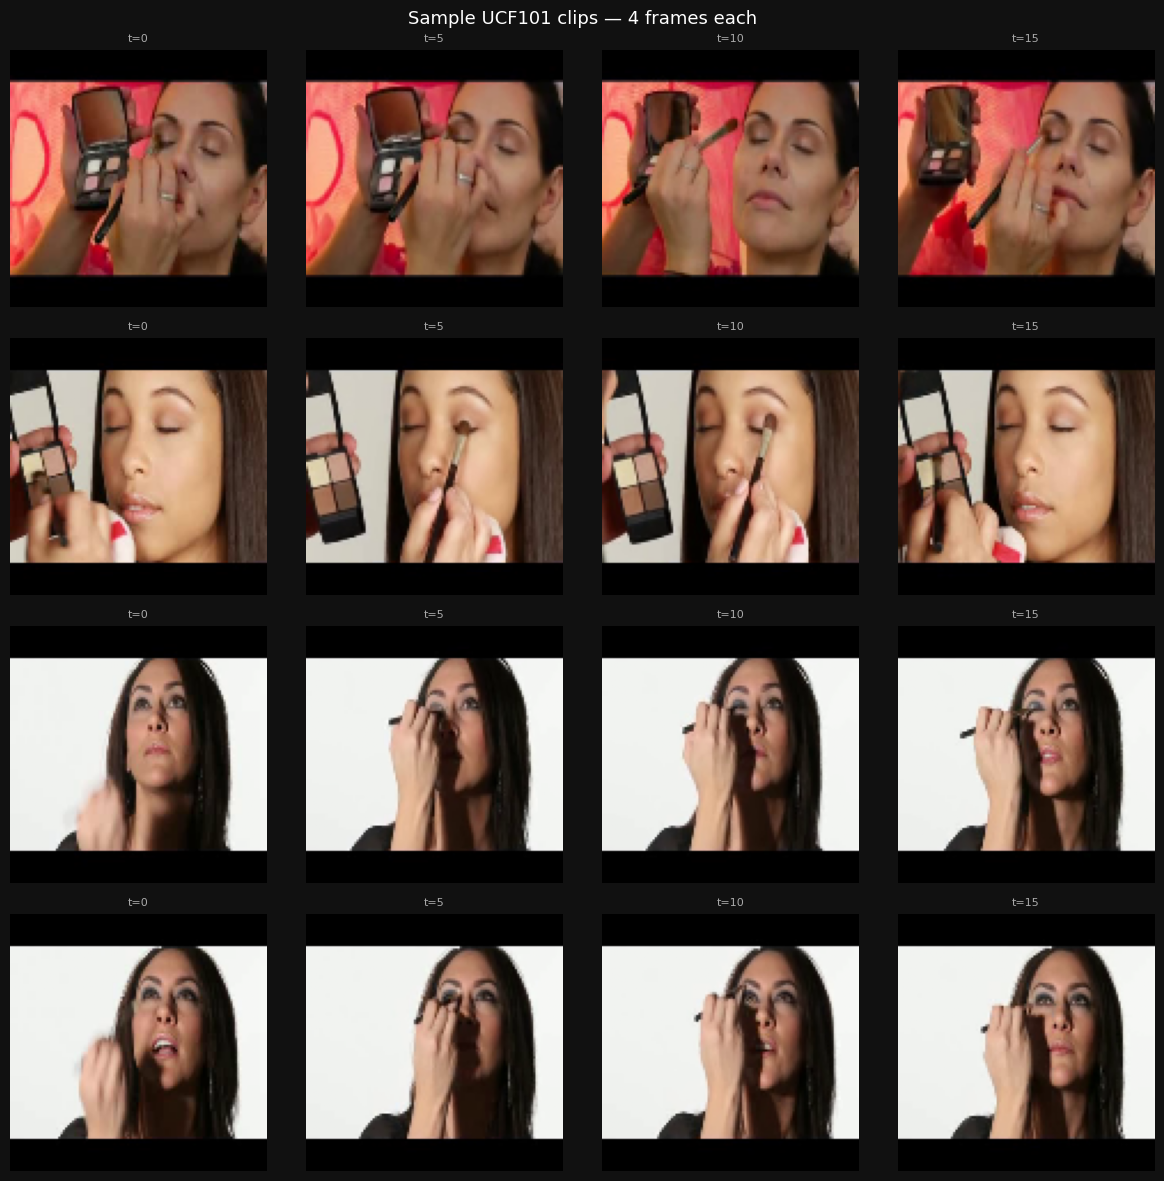

In [8]:
def denormalize(tensor):
  """Undo ImageNet normalisation for display."""
  mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
  std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
  return torch.clamp(tensor * std + mean, 0, 1)

# Show 4 clips × 4 sampled frames
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.patch.set_facecolor('#111')
fig.suptitle("Sample UCF101 clips — 4 frames each", color='white', fontsize=13)

shown = 0
for clip, label in train_ds:
  if shown >= 4: break
  frame_indices = [0, 5, 10, 15]
  for col, fi in enumerate(frame_indices):
    ax = axes[shown][col]
    frame = denormalize(clip[:, fi, :, :]).permute(1, 2, 0).numpy()
    ax.imshow(frame)
    ax.axis('off')
    if col == 0:
      ax.set_ylabel(CLASS_NAMES[label], color='white', fontsize=9, labelpad=6)
    ax.set_title(f"t={fi}", color='#aaa', fontsize=8)
  shown += 1

plt.tight_layout()
plt.show()


### 1.4: 2D CNN on Frames: The Baseline

We process each frame through a 2D CNN independently and **average** the frame-level features to get a video-level representation.

**Key question:** Can this averaged representation distinguish different actions?


In [9]:
class Frame2DCNN(nn.Module):
  """
  Applies a small 2D CNN to each frame independently,
  then mean-pools across time to get a clip-level embedding.

  Input:  (B, C, T, H, W)
  Output: (B, num_classes)
  """
  def __init__(self, num_classes):
    super().__init__()
    # from 3 colour channels to 16 learned feature channels
    self.spatial = nn.Sequential(
      nn.Conv2d(3,  16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
      nn.AdaptiveAvgPool2d((1, 1)),    # (B, 64, 1, 1)
    )
    self.classifier = nn.Linear(64, num_classes)

  def forward(self, x):
    B, C, T, H, W = x.shape
    # Reshape: treat each frame as an independent image
    # 2d cnn only understands (batch, C, H, W), has no concept of Time
    # a batch of B clips each with T frames can be understood as a batch of B*T images
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)   # (B*T, C, H, W)
    #self.spatial(x) gives (B, 64, 1, 1), then flatten(1) means flatten from dim=1, that is 64
    feats = self.spatial(x).flatten(1)                        # (B*T, 64)
    feats = feats.reshape(B, T, -1).mean(dim=1)              # (B, 64) — TIME POOLED AWAY (since T is at dim=1) #temporal averaging- shuffling makes no sense since it has already been averaged across time
    return self.classifier(feats) # (B, num_classes)

  def get_features(self, x):
    """Return the pooled embedding without classification head."""
    #same as forward but stops before classifier, returning raw 64-d
    # embedding. Used later to compute cosine similarity between clips
    B, C, T, H, W = x.shape
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
    feats = self.spatial(x).flatten(1)
    return feats.reshape(B, T, -1).mean(dim=1)   # (B, 64)


model_2d = Frame2DCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
summary(model_2d, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE), device=DEVICE)


Layer (type:depth-idx)                   Output Shape              Param #
Frame2DCNN                               [1, 10]                   --
├─Sequential: 1-1                        [16, 64, 1, 1]            --
│    └─Conv2d: 2-1                       [16, 16, 112, 112]        448
│    └─ReLU: 2-2                         [16, 16, 112, 112]        --
│    └─MaxPool2d: 2-3                    [16, 16, 56, 56]          --
│    └─Conv2d: 2-4                       [16, 32, 56, 56]          4,640
│    └─ReLU: 2-5                         [16, 32, 56, 56]          --
│    └─MaxPool2d: 2-6                    [16, 32, 28, 28]          --
│    └─Conv2d: 2-7                       [16, 64, 28, 28]          18,496
│    └─ReLU: 2-8                         [16, 64, 28, 28]          --
│    └─AdaptiveAvgPool2d: 2-9            [16, 64, 1, 1]            --
├─Linear: 1-2                            [1, 10]                   650
Total params: 24,234
Trainable params: 24,234
Non-trainable params: 0
Total 

Clips collected per class:
  class 0 (ApplyEyeMakeup): 3 clips
  class 1 (ApplyLipstick): 3 clips
  class 2 (Archery): 3 clips
  class 3 (BabyCrawling): 3 clips
  class 4 (BalanceBeam): 3 clips
  class 5 (BandMarching): 3 clips
  class 6 (BaseballPitch): 3 clips
  class 7 (Basketball): 3 clips
  class 8 (BasketballDunk): 3 clips
  class 9 (BenchPress): 3 clips


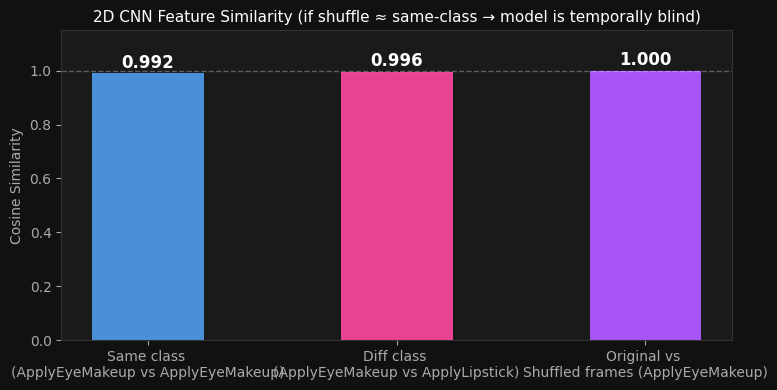

 Same class similarity    : 0.992
 Different class similarity: 0.996
 Original vs shuffled      : 1.000
 → If shuffle ≈ same class, the 2D CNN cannot use temporal order.


In [10]:
# Demonstrate temporal blindness
# Take two clips from DIFFERENT classes and compare their 2D features

model_2d.eval()
clips_by_class = defaultdict(list)

# Iterate full test set, collect up to 3 clips per class
for clip, label in test_ds:
  if len(clips_by_class[label]) < 3:
    clips_by_class[label].append(clip)

print("Clips collected per class:")
for i, name in enumerate(CLASS_NAMES):
  print(f"  class {i} ({name}): {len(clips_by_class[i])} clips")

with torch.no_grad():
  # Compare same class vs different class
  c0, c1 = CLASS_NAMES[0], CLASS_NAMES[1]
  f_c0_a = model_2d.get_features(clips_by_class[0][0].unsqueeze(0).to(DEVICE)).cpu()
  f_c0_b = model_2d.get_features(clips_by_class[0][1].unsqueeze(0).to(DEVICE)).cpu()
  f_c1_a = model_2d.get_features(clips_by_class[1][0].unsqueeze(0).to(DEVICE)).cpu()

  # Shuffled temporal order
  clip_shuffled = clips_by_class[0][0].clone()
  perm = torch.randperm(N_FRAMES)
  clip_shuffled = clip_shuffled[:, perm, :, :]  # shuffle along T
  f_c0_shuffled = model_2d.get_features(clip_shuffled.unsqueeze(0).to(DEVICE)).cpu()

#cosine similarity measures angle between two vectors :
# 1 means identical direction, 0 means perpendicular, -1 means opposite
def cosine_sim(a, b):
  return F.cosine_similarity(a, b).item()

sim_same    = cosine_sim(f_c0_a, f_c0_b)
sim_diff    = cosine_sim(f_c0_a, f_c1_a)
sim_shuffle = cosine_sim(f_c0_a, f_c0_shuffled)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')

labels_bar = [
  f'Same class \n({c0} vs {c0})',
  f'Diff class \n({c0} vs {c1})',
  f'Original vs \nShuffled frames ({c0})',
]
sims   = [sim_same, sim_diff, sim_shuffle]
colors = ['#4a90d9', '#e84393', '#a855f7']
bars   = ax.bar(labels_bar, sims, color=colors, width=0.45)

ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='white', linestyle='--', linewidth=1, alpha=0.3)
ax.set_ylabel("Cosine Similarity", color='#aaa')
ax.set_title("2D CNN Feature Similarity (if shuffle ≈ same-class → model is temporally blind)",
             color='white', fontsize=11)
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
for bar, v in zip(bars, sims):
  ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
          ha='center', color='white', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

print(f" Same class similarity    : {sim_same:.3f}")
print(f" Different class similarity: {sim_diff:.3f}")
print(f" Original vs shuffled      : {sim_shuffle:.3f}")
print(f" → If shuffle ≈ same class, the 2D CNN cannot use temporal order.")


The 2D CNN thinks two different action classes are more similar (0.996) than two clips of the same class (0.992). And shuffling the frames gives a perfect 1.0, the model produces literally identical features regardless of frame order.
the 2D CNN is completely blind to motion and temporal order. It's essentially just recognising background, clothing colour, scene context, not the action itself.

## Section 2: The Fix: 3D Convolutions

### How 3D Conv differs from 2D Conv

| | 2D Conv | 3D Conv |
|---|---|---|
| Input | `(B, C, H, W)` | `(B, C, T, H, W)` |
| Kernel | `(C_out, C_in, kH, kW)` | `(C_out, C_in, kT, kH, kW)` |
| Slides over | Height × Width | **Time × Height × Width** |
| Detects | Edges, textures, objects | **Motion patterns, spatiotemporal features** |
| PyTorch class | `nn.Conv2d` | `nn.Conv3d` |

The temporal kernel dimension `kT` is what makes the difference, a single filter can now respond to *"bright region moving rightward over 3 frames"* as a learned pattern.


### 2.1: Visualising the 3D Convolution Operation


>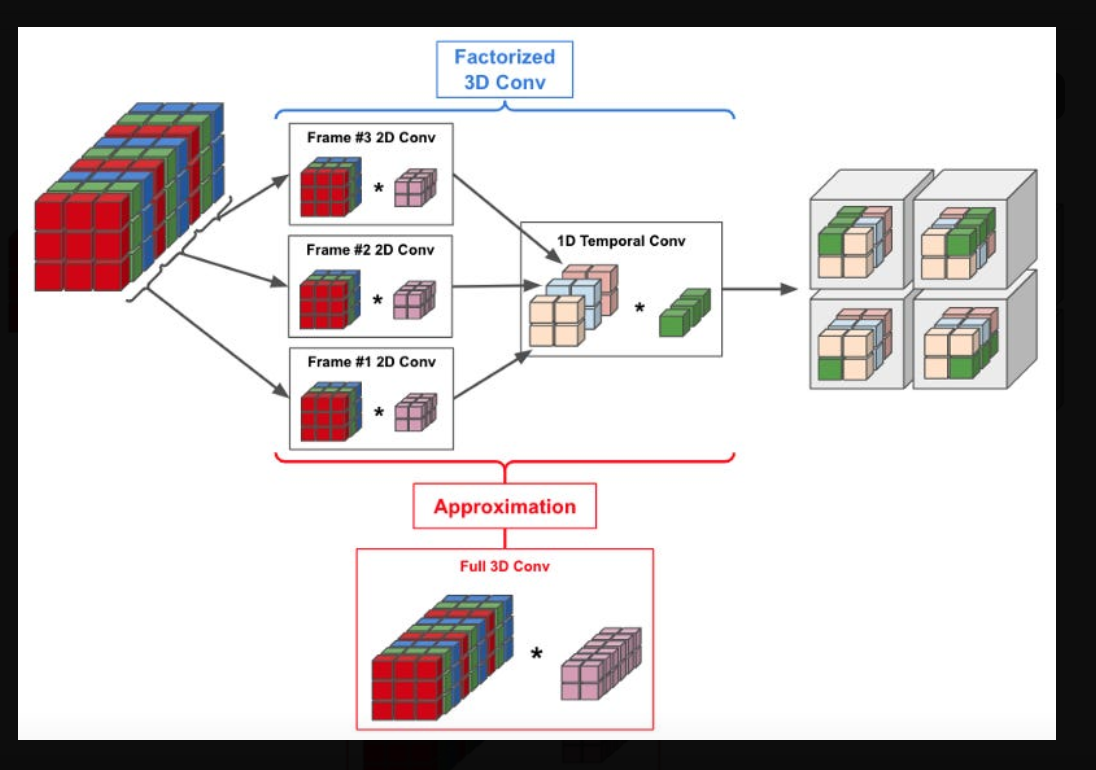
```
Kernel shape:  (C_out, C_in, kT, kH, kW)
                                │   │   └─ width
                                │   └───── height
                                └───────── temporal depth  ← the new dimension
```

Unlike the 2D case where each frame is processed independently, the 3D kernel "sees" multiple consecutive frames at once, so it can detect how pixels change over time.


### 2.2: Building a 3D CNN (C3D-style)

We implement a simplified **C3D** architecture (Tran et al., 2015), the seminal work that showed 3D convolutions work well for video.

Full C3D uses 8 conv layers with `3×3×3` kernels throughout. We use a lighter 4-block version suitable for Colab.


In [11]:
class C3D(nn.Module):
  """
  Simplified C3D architecture for video classification.
  Based on Tran et al. (2015), Learning Spatiotemporal Features
  with 3D Convolutional Networks.

  Input shape : (B, C, T, H, W)  e.g. (8, 3, 16, 112, 112)
  Output shape: (B, num_classes)
  """
  def __init__(self, num_classes, dropout=0.5):
    super().__init__()

    self.features = nn.Sequential(
      # Block 1 large temporal kernel to capture coarse motion
      nn.Conv3d(3,  64, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2)),        # spatial only

      # Block 2
      nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)),        # spatiotemporal

      # Block 3
      nn.Conv3d(128, 256, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.Conv3d(256, 256, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)),

      # Block 4
      nn.Conv3d(256, 512, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.Conv3d(512, 512, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.AdaptiveAvgPool3d((1, 1, 1)),                           # (B, 512, 1, 1, 1)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(dropout),
      nn.Linear(256, num_classes)
    )

    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.zeros_(m.bias)
      elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.classifier(self.features(x))

  def get_features(self, x):
    """Return 512-d embedding without classification head."""
    return self.features(x).flatten(1)


model_3d = C3D(num_classes=len(CLASS_NAMES)).to(DEVICE)
summary(model_3d, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE),
        col_names=["input_size", "output_size", "num_params"], device=DEVICE)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
C3D                                      [1, 3, 16, 112, 112]      [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 16, 112, 112]      [1, 512, 1, 1, 1]         --
│    └─Conv3d: 2-1                       [1, 3, 16, 112, 112]      [1, 64, 16, 112, 112]     5,248
│    └─ReLU: 2-2                         [1, 64, 16, 112, 112]     [1, 64, 16, 112, 112]     --
│    └─MaxPool3d: 2-3                    [1, 64, 16, 112, 112]     [1, 64, 16, 56, 56]       --
│    └─Conv3d: 2-4                       [1, 64, 16, 56, 56]       [1, 128, 16, 56, 56]      221,312
│    └─ReLU: 2-5                         [1, 128, 16, 56, 56]      [1, 128, 16, 56, 56]      --
│    └─MaxPool3d: 2-6                    [1, 128, 16, 56, 56]      [1, 128, 8, 28, 28]       --
│    └─Conv3d: 2-7                       [1, 128, 8, 28, 28]       [1, 256, 8, 28, 28]       884,992
│    └─ReLU: 2-8      

### 2.3: Forward Pass: Tensor Shape Walkthrough

Let's trace a single batch through the network and print shapes at every layer.


In [12]:
model_3d.eval()
dummy = torch.zeros(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE).to(DEVICE)

print("Forward pass:shape at each operation")
print("=" * 65)
print(f"  Input                           {tuple(dummy.shape)}")

x = dummy
layer_info = [
  ("Conv3d(3→64)  + ReLU",              model_3d.features[0]),
  ("MaxPool3d(1,2,2) — spatial only",   model_3d.features[2]),
  ("Conv3d(64→128) + ReLU",             model_3d.features[3]),
  ("MaxPool3d(2,2,2) — spatio-temporal",model_3d.features[5]),
  ("Conv3d(128→256) + ReLU",            model_3d.features[6]),
  ("Conv3d(256→256) + ReLU",            model_3d.features[8]),
  ("MaxPool3d(2,2,2)",                  model_3d.features[10]),
  ("Conv3d(256→512) + ReLU",            model_3d.features[11]),
  ("Conv3d(512→512) + ReLU",            model_3d.features[13]),
  ("AdaptiveAvgPool3d → (1,1,1)",       model_3d.features[15]),
]

with torch.no_grad():
  for name, layer in layer_info:
    x = layer(x)
    print(f"  {name:<40} {tuple(x.shape)}")

x_flat = x.flatten(1)
print(f"  {'Flatten':<40} {tuple(x_flat.shape)}")
print("=" * 65)
print(f"\n  The (B, 512) vector is the clip-level embedding.")
print(f"  It encodes BOTH spatial and temporal patterns from the video.")


Forward pass:shape at each operation
  Input                           (1, 3, 16, 112, 112)
  Conv3d(3→64)  + ReLU                     (1, 64, 16, 112, 112)
  MaxPool3d(1,2,2) — spatial only          (1, 64, 16, 56, 56)
  Conv3d(64→128) + ReLU                    (1, 128, 16, 56, 56)
  MaxPool3d(2,2,2) — spatio-temporal       (1, 128, 8, 28, 28)
  Conv3d(128→256) + ReLU                   (1, 256, 8, 28, 28)
  Conv3d(256→256) + ReLU                   (1, 256, 8, 28, 28)
  MaxPool3d(2,2,2)                         (1, 256, 4, 14, 14)
  Conv3d(256→512) + ReLU                   (1, 512, 4, 14, 14)
  Conv3d(512→512) + ReLU                   (1, 512, 4, 14, 14)
  AdaptiveAvgPool3d → (1,1,1)              (1, 512, 1, 1, 1)
  Flatten                                  (1, 512)

  The (B, 512) vector is the clip-level embedding.
  It encodes BOTH spatial and temporal patterns from the video.


## Section 3:Training & Evaluation

Now we train the C3D model on our UCF101 subset and evaluate it properly.



In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
  model.train()
  total_loss, correct, total = 0.0, 0, 0
  for clips, labels in loader:
    clips, labels = clips.to(device), labels.to(device)
    optimizer.zero_grad()
    logits = model(clips)
    loss   = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * clips.size(0)
    correct    += (logits.argmax(1) == labels).sum().item()
    total      += clips.size(0)
  return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  all_preds, all_labels = [], []
  for clips, labels in loader:
    clips, labels = clips.to(device), labels.to(device)
    logits = model(clips)
    loss   = criterion(logits, labels)
    total_loss += loss.item() * clips.size(0)
    preds = logits.argmax(1)
    correct += (preds == labels).sum().item()
    total   += clips.size(0)
    all_preds.extend(preds.cpu().tolist())
    all_labels.extend(labels.cpu().tolist())
  return total_loss / total, correct / total, all_preds, all_labels


In [14]:
EPOCHS   = 10
LR       = 1e-3
WD       = 1e-4

optimizer = torch.optim.AdamW(model_3d.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()
  tr_loss, tr_acc = train_one_epoch(model_3d, train_loader, optimizer, criterion, DEVICE)
  vl_loss, vl_acc, _, _ = evaluate(model_3d, test_loader, criterion, DEVICE)
  scheduler.step()

  history['train_loss'].append(tr_loss)
  history['train_acc'].append(tr_acc)
  history['val_loss'].append(vl_loss)
  history['val_acc'].append(vl_acc)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")


 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      4.5680      8.00%    2.3018   14.67%  (54s)
     2      2.3031      7.33%    2.3021   13.33%  (56s)
     3      2.3043      7.00%    2.3022   13.33%  (56s)
     4      2.3032      9.33%    2.3021   12.00%  (55s)
     5      2.3036     10.33%    2.3020   13.33%  (56s)
     6      2.3029     12.00%    2.3019   12.00%  (55s)
     7      2.3030      9.33%    2.3020   13.33%  (56s)
     8      2.3029     11.67%    2.3021   12.00%  (56s)
     9      2.3029     10.67%    2.3022   12.00%  (56s)
    10      2.3020     11.33%    2.3022   12.00%  (56s)


### 3.1:Training Curves


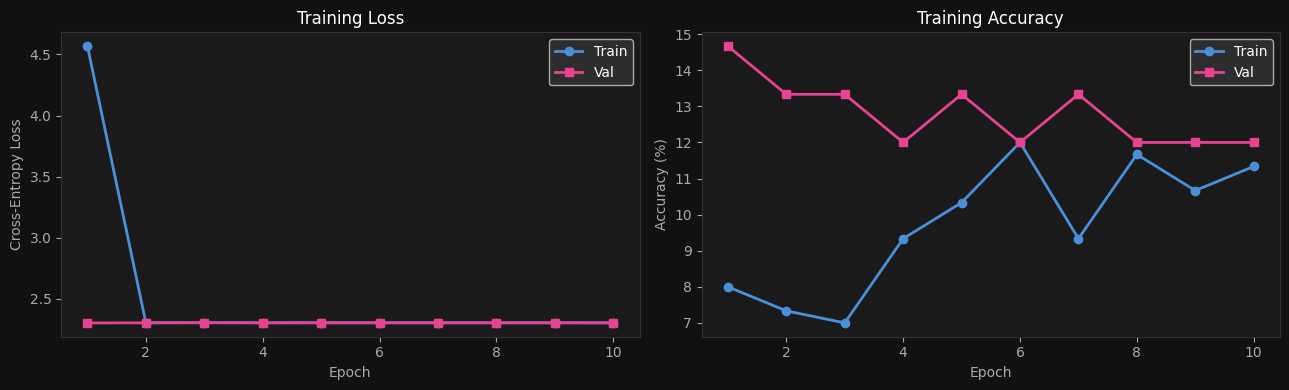

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#111')
epochs_x = range(1, EPOCHS + 1)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
  ax.set_facecolor('#1a1a1a')
  tr = history[f'train_{metric}']
  vl = history[f'val_{metric}']
  if metric == 'acc':
      tr = [v * 100 for v in tr]; vl = [v * 100 for v in vl]
  ax.plot(epochs_x, tr, 'o-', color='#4a90d9', label='Train', linewidth=2)
  ax.plot(epochs_x, vl, 's-', color='#e84393', label='Val',   linewidth=2)
  ax.set_title(f'Training {title}', color='white')
  ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#aaa')
  ax.legend(facecolor='#333', labelcolor='white')
  for spine in ax.spines.values(): spine.set_edgecolor('#333')
  if metric == 'acc': ax.set_ylabel('Accuracy (%)', color='#aaa')
  else: ax.set_ylabel('Cross-Entropy Loss', color='#aaa')

plt.tight_layout(); plt.show()


In [16]:
total_params = sum(p.numel() for p in model_3d.parameters())
trainable_params = sum(p.numel() for p in model_3d.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params    : 13,633,034
Trainable params: 13,633,034


From the plots it is evident that the model is not learning at all. Both training and val loss flatline at 2.3 approx, which is exactly log(10) = 2.302, which is the cross entropy loss you'd get from random guessing on 10 classes. Accuracy hovers around 10% with no upward trend, again just a random chance.

This happens since we are trying to train a model with approx 14000000 on only 250 video clips. Even if data is sufficient 3d cnns need hundreds of epochs to converge from scratch. This is why transfer learning exists. Instead of training from random weights on 250 clips, we take a model already pretrained on 400,000+ clips (Kinetics-400) and only fine-tune the final classification layer on our data.

### 3.2:Confusion Matrix

The confusion matrix shows which classes the model confuses, much more informative than a single accuracy number.


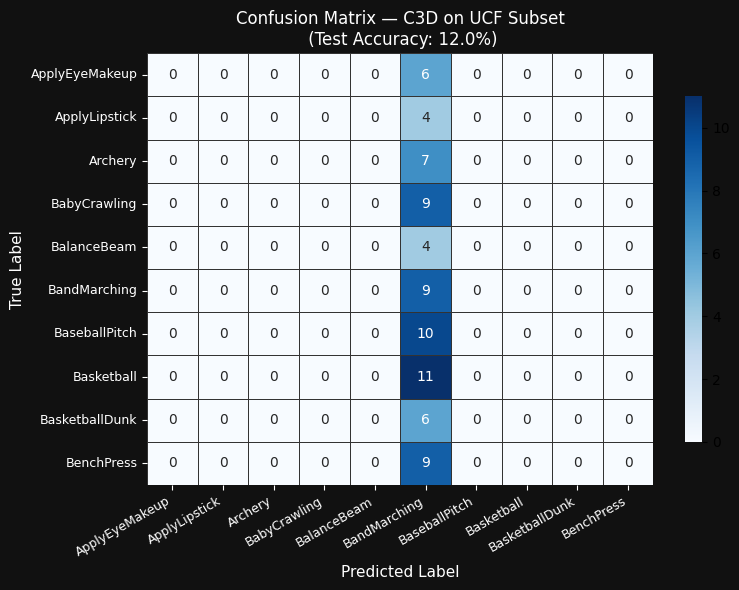

In [17]:
_, test_acc, y_pred, y_true = evaluate(model_3d, test_loader, criterion, DEVICE)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#111')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#333',
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_xlabel('Predicted Label', color='white', fontsize=11)
ax.set_ylabel('True Label', color='white', fontsize=11)
ax.set_title(f'Confusion Matrix — C3D on UCF Subset\n (Test Accuracy: {test_acc*100:.1f}%)',
             color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


### 3.3:Per-Class Precision, Recall, F1


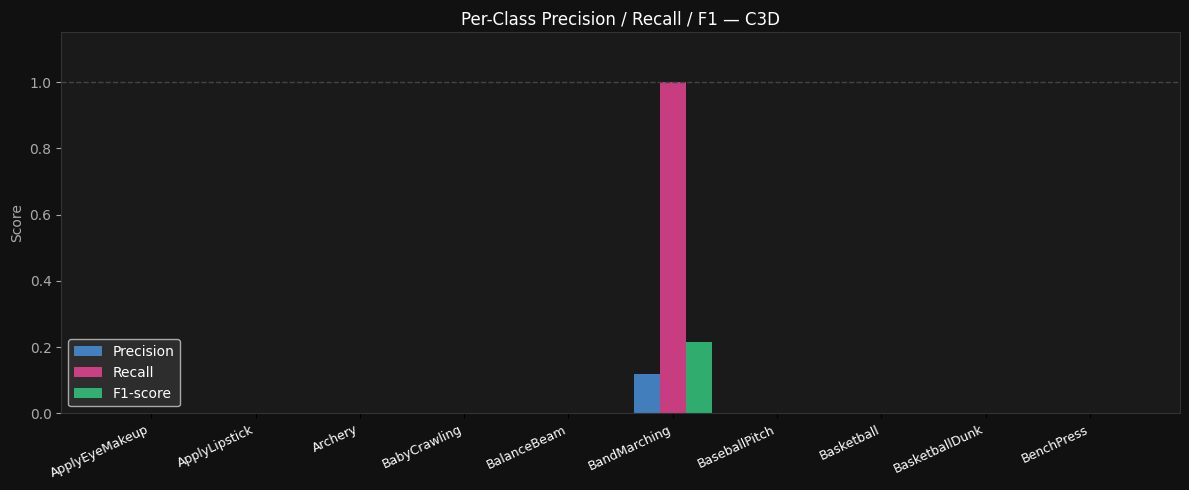


Class                      Precision  Recall      F1  Support
------------------------------------------------------------
  ApplyEyeMakeup               0.000   0.000   0.000        6
  ApplyLipstick                0.000   0.000   0.000        4
  Archery                      0.000   0.000   0.000        7
  BabyCrawling                 0.000   0.000   0.000        9
  BalanceBeam                  0.000   0.000   0.000        4
  BandMarching                 0.120   1.000   0.214        9
  BaseballPitch                0.000   0.000   0.000       10
  Basketball                   0.000   0.000   0.000       11
  BasketballDunk               0.000   0.000   0.000        6
  BenchPress                   0.000   0.000   0.000        9
------------------------------------------------------------
  Macro avg                    0.012   0.100   0.021


In [18]:
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

# Bar chart
metrics   = ['precision', 'recall', 'f1-score']
x         = np.arange(len(CLASS_NAMES))
width     = 0.25
bar_colors = ['#4a90d9', '#e84393', '#34c77e']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
  vals = [report[c][metric] for c in CLASS_NAMES]
  bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(),
                color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', color='white', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', color='#aaa')
ax.set_title('Per-Class Precision / Recall / F1 — C3D', color='white', fontsize=12)
ax.legend(facecolor='#333', labelcolor='white')
ax.tick_params(axis='y', colors='#aaa')
ax.axhline(1.0, color='#444', linestyle='--', linewidth=1)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout(); plt.show()

# Print table
print(f"\n{'Class':<25}  {'Precision':>9}  {'Recall':>6}  {'F1':>6}  {'Support':>7}")
print("-" * 60)
for cls in CLASS_NAMES:
  r = report[cls]
  print(f"  {cls:<23}  {r['precision']:>9.3f}  {r['recall']:>6.3f}  "
        f"{r['f1-score']:>6.3f}  {int(r['support']):>7}")
print("-" * 60)
print(f"  {'Macro avg':<23}  "
      f"{report['macro avg']['precision']:>9.3f}  "
      f"{report['macro avg']['recall']:>6.3f}  "
      f"{report['macro avg']['f1-score']:>6.3f}")


The confusion matrix reveals complete class collapse ,the model predicted BandMarching for every single test sample regardless of the true class. This gives BandMarching a recall of 1.0 (it never misses an NandMarching clip) but a precision of only 0.12 (only 3 in 25 predictions is actually correct). Every other class has precision, recall and F1 of exactly 0, they were never predicted once.
Overall test accuracy is 12%, which is actually just above random chance (10% for 10 classes),confirming the model has learned nothing useful and is simply collapsing to a single output.


## Section 4:S3D: A Pretrained Video Model

Training 3D CNNs from scratch is expensive, hours on GPUs, thousands of labelled clips.  
In practice, we use **pretrained video models** and fine-tune them.

### What is S3D?

**S3D** (Separable 3D CNN, Xie et al. 2018) is an efficient video model that factorises
standard 3D convolutions into separate temporal and spatial convolutions,similar in spirit
to R(2+1)D but applied throughout the entire network.

| Property | Value |
|---|---|
| Architecture | Factorised 3D convolutions (1D temporal + 2D spatial) |
| Pretrained on | Kinetics-400 — 400 classes, 240K+ clips |
| Params | ~8M |
| Available in | `torchvision.models.video.s3d` ,no extra dependencies |



In [19]:
from torchvision.models.video import MViT_V2_S_Weights, mvit_v2_s
# Note: torchvision has MViTv2 (closely related efficient video transformer)

from torchvision.models.video import s3d, S3D_Weights

# S3D (Separable 3D CNN, pretrained on Kinetics-400)

print("Loading S3D pretrained on Kinetics-400...")
s3d_model = s3d(weights=S3D_Weights.KINETICS400_V1)
s3d_model.eval()
print(f"S3D loaded  ({sum(p.numel() for p in s3d_model.parameters())/1e6:.1f}M params)")
print(f"Pretrained on: Kinetics-400 (400 action classes)")


Loading S3D pretrained on Kinetics-400...
Downloading: "https://download.pytorch.org/models/s3d-d76dad2f.pth" to /root/.cache/torch/hub/checkpoints/s3d-d76dad2f.pth


100%|██████████| 32.0M/32.0M [00:00<00:00, 41.4MB/s]


S3D loaded  (8.3M params)
Pretrained on: Kinetics-400 (400 action classes)


### 4.1: Zero-Shot Inference on UCF Clips

Let's run S3D (pretrained, no fine-tuning) on our UCF clips and see what it predicts.


In [20]:
# Kinetics-400 class names
K400_LABELS = S3D_Weights.KINETICS400_V1.meta['categories']

s3d_model = s3d_model.to(DEVICE)
s3d_model.eval()

# S3D expects (B, C, T, H, W) with ImageNet normalisation,same as our loader
# Run inference on a few test clips
results = []
with torch.no_grad():
    for clips, labels in test_loader:
        clips = clips.to(DEVICE)
        # Resize T to 16, H/W to 224 as S3D expects
        clips_r = F.interpolate(
            clips.view(-1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE).permute(0,2,1,3,4).reshape(-1,3,CLIP_SIZE,CLIP_SIZE),
            size=(224, 224)
        ).reshape(clips.shape[0], 3, N_FRAMES, 224, 224)
        logits = s3d_model(clips_r)
        probs  = F.softmax(logits, dim=1)
        top5   = probs.topk(5, dim=1)
        for i in range(clips.shape[0]):
            results.append({
                'true_ucf': CLASS_NAMES[labels[i].item()],
                'top1_k400': K400_LABELS[top5.indices[i, 0].item()],
                'top1_prob': top5.values[i, 0].item(),
                'top5': [(K400_LABELS[top5.indices[i, j].item()],
                          top5.values[i, j].item()) for j in range(5)]
            })
        if len(results) >= 12: break

# Display results table
print(f"{'UCF True Class':<25}  {'S3D Top-1 (Kinetics-400)':<35}  Confidence")
print("-" * 75)
for r in results[:12]:
    match = "yes" if r['true_ucf'].lower() in r['top1_k400'].lower() else " no "
    print(f"  {r['true_ucf']:<23}  {r['top1_k400']:<35}  {r['top1_prob']*100:.1f}%  {match}")


UCF True Class             S3D Top-1 (Kinetics-400)             Confidence
---------------------------------------------------------------------------
  ApplyEyeMakeup           whistling                            62.8%   no 
  ApplyEyeMakeup           whistling                            25.7%   no 
  ApplyEyeMakeup           fixing hair                          16.1%   no 
  ApplyEyeMakeup           brush painting                       45.7%   no 
  ApplyEyeMakeup           brush painting                       83.2%   no 
  ApplyEyeMakeup           brush painting                       86.8%   no 
  ApplyLipstick            pumping fist                         27.0%   no 
  ApplyLipstick            fixing hair                          19.1%   no 
  ApplyLipstick            balloon blowing                      48.0%   no 
  ApplyLipstick            brushing teeth                       56.9%   no 
  Archery                  hula hooping                         70.2%   no 
  Archery    

### 4.2: Fine-Tuning S3D on Our UCF Subset

Replace the Kinetics-400 head with our 10-class head and fine-tune: this is **transfer learning**.


In [21]:
# Replace classification head
import copy

s3d_ft = copy.deepcopy(s3d_model)
#classifier block of S3D looks like
# classifier =
# Sequential(
#     Dropout
#     Conv3d(1024 → 400)
# )

# Freeze all layers first
for param in s3d_ft.parameters():
    param.requires_grad = False

# Replace final classifier: S3D has a 'classifier' Sequential block
in_features = s3d_ft.classifier[1].in_channels   # original = 400
s3d_ft.classifier[1] = nn.Conv3d(in_features, len(CLASS_NAMES), kernel_size=1)

# Unfreeze only the new head (+ optionally last backbone block)
for param in s3d_ft.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in s3d_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in s3d_ft.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

s3d_ft = s3d_ft.to(DEVICE)


Trainable params: 10,250 / 7,920,298  (0.1%)


In [22]:
# Create 224×224 dataloaders specifically for S3D
train_ds_224 = UCFClipDataset(RAW_DIR / "train", CLASS_NAMES, n_frames=16, size=224)
test_ds_224  = UCFClipDataset(RAW_DIR / "test",  CLASS_NAMES, n_frames=16, size=224)

train_loader_224 = DataLoader(train_ds_224, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
test_loader_224  = DataLoader(test_ds_224,  batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f"S3D dataloaders ready, clip shape: {train_ds_224[0][0].shape}")

# Fine-tuning loop
FT_EPOCHS = 3
FT_LR     = 5e-4

ft_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, s3d_ft.parameters()), lr=FT_LR)
ft_criterion = nn.CrossEntropyLoss()

ft_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, FT_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(s3d_ft, train_loader_224, ft_optimizer, ft_criterion, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(s3d_ft, test_loader_224, ft_criterion, DEVICE)
    ft_history['train_loss'].append(tr_loss); ft_history['train_acc'].append(tr_acc)
    ft_history['val_loss'].append(vl_loss);   ft_history['val_acc'].append(vl_acc)
    print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
          f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")

S3D dataloaders ready, clip shape: torch.Size([3, 16, 224, 224])
 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      2.1756     20.33%    1.5045   68.00%  (59s)
     2      1.6385     60.00%    0.9275   96.00%  (58s)
     3      1.2662     75.33%    0.6265   94.67%  (56s)


### 4.3:Final Comparison: 2D CNN vs C3D vs S3D (fine-tuned)


In [23]:
# Train 2D CNN baseline for fair comparison
model_2d_trained = Frame2DCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
opt_2d = torch.optim.AdamW(model_2d_trained.parameters(), lr=LR, weight_decay=WD)
sch_2d = torch.optim.lr_scheduler.CosineAnnealingLR(opt_2d, T_max=EPOCHS)

print("Training 2D CNN baseline...")
for epoch in range(EPOCHS):
    train_one_epoch(model_2d_trained, train_loader, opt_2d, nn.CrossEntropyLoss(), DEVICE)
    sch_2d.step()



Training 2D CNN baseline...


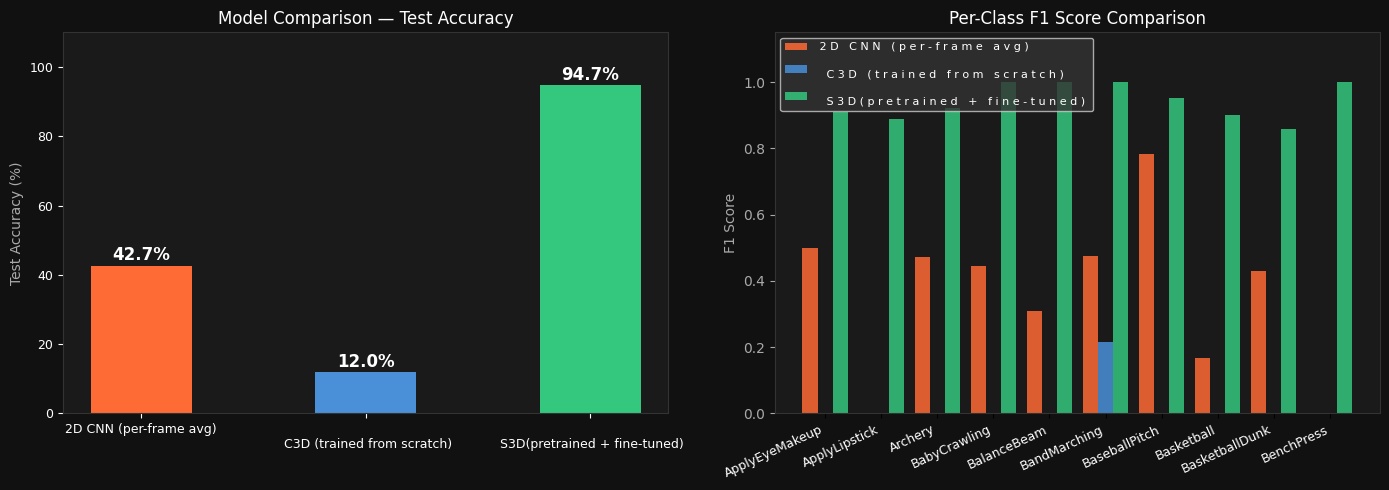

Final Results
  2D CNN (per-frame avg)              42.67%
    C3D (trained from scratch)        12.00%
    S3D(pretrained + fine-tuned)      94.67%


In [24]:
_, acc_2d, pred_2d, true_2d = evaluate(model_2d_trained, test_loader, nn.CrossEntropyLoss(), DEVICE)
_, acc_3d, pred_3d, true_3d = evaluate(model_3d,test_loader, criterion,DEVICE)
_, acc_ft, pred_ft, true_ft = evaluate(s3d_ft, test_loader_224, ft_criterion,DEVICE)

# Summary plot
models_info = {'2D CNN (per-frame avg)': (acc_2d, pred_2d, true_2d),
    '\n C3D (trained from scratch)': (acc_3d, pred_3d, true_3d),
    '\n S3D(pretrained + fine-tuned)': (acc_ft, pred_ft, true_ft),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#111')

# Accuracy bar
ax = axes[0]; ax.set_facecolor('#1a1a1a')
names  = list(models_info.keys())
accs   = [v[0]*100 for v in models_info.values()]
colors_m = ['#ff6b35', '#4a90d9', '#34c77e']
bars = ax.bar(names, accs, color=colors_m, width=0.45)
ax.set_ylim(0, 110); ax.set_ylabel('Test Accuracy (%)', color='#aaa')
ax.set_title('Model Comparison — Test Accuracy', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=9)
for spine in ax.spines.values(): spine.set_edgecolor('#333')
for bar, v in zip(bars, accs):
  ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.1f}%',
          ha='center', color='white', fontsize=12, fontweight='bold')

# Per-class F1 comparison
ax2 = axes[1]; ax2.set_facecolor('#1a1a1a')
x = np.arange(len(CLASS_NAMES)); w = 0.27

for i, (name, (_, preds, trues), color) in enumerate(zip(names, models_info.values(), colors_m)):
    f1s = f1_score(trues, preds, average=None, labels=list(range(len(CLASS_NAMES))))
    ax2.bar(x + i*w, f1s, w, label=name.replace('', ' '), color=color, alpha=0.85)

ax2.set_xticks(x + w)
ax2.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', color='white', fontsize=9)
ax2.set_ylim(0, 1.15); ax2.set_ylabel('F1 Score', color='#aaa')
ax2.set_title('Per-Class F1 Score Comparison', color='white', fontsize=12)
ax2.legend(facecolor='#333', labelcolor='white', fontsize=8)
ax2.tick_params(axis='y', colors='#aaa')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout(); plt.show()

print("Final Results")
print("=" * 45)
for name, (acc, _, _) in models_info.items():
  print(f"  {name.replace(chr(10),' '):<35} {acc*100:.2f}%")
print("=" * 45)


##Quick Reference

```
PYTORCH VIDEO TENSOR CONVENTION
─────────────────────────────────────────────────────────────
Stage          Shape              Notes
─────────────────────────────────────────────────────────────
Raw video      (T, H, W, C)      from cv2 / decord
After permute  (C, T, H, W)      PyTorch convention
Batched input  (B, C, T, H, W)   fed to model
After Conv3d   (B, F, T', H', W') F = num filters
After AvgPool  (B, F, 1, 1, 1)
After flatten  (B, F)            clip embedding
After fc       (B, num_classes)  logits

─────────────────────────────────────────────────────────────
KEY PyTorch VIDEO LAYERS
─────────────────────────────────────────────────────────────
nn.Conv3d(C_in, C_out, kernel_size=(kT, kH, kW))
nn.MaxPool3d(kernel_size=(pT, pH, pW))
nn.AdaptiveAvgPool3d((1, 1, 1))   # global pool over T×H×W

─────────────────────────────────────────────────────────────
COMMON PITFALL
─────────────────────────────────────────────────────────────
cv2 reads frames as (H, W, C) in BGR order.
Remember: cvtColor to RGB, then permute to (C, T, H, W).

─────────────────────────────────────────────────────────────
PRETRAINED MODELS IN TORCHVISION (≥0.13)
─────────────────────────────────────────────────────────────
torchvision.models.video.r3d_18          ResNet3D-18, Kinetics-400
torchvision.models.video.r2plus1d_18     R(2+1)D-18, Kinetics-400
torchvision.models.video.s3d             S3D, Kinetics-400
torchvision.models.video.mvit_v2_s       MViTv2-S, Kinetics-400
```

